In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

In [2]:
dataset_path = r"C:\Users\AANYA SHARMA\Desktop\PRODIGY_ML_04\leapgesture_data\leapGestRecog"

subjects = os.listdir(dataset_path)
print("Subject folders:", subjects)

sample_subject_path = os.path.join(dataset_path, subjects[0])
gesture_classes = os.listdir(sample_subject_path)
print("Gesture classes:", gesture_classes)

Subject folders: ['00', '01', '02', '03', '04', '05', '06', '07', '08', '09']
Gesture classes: ['01_palm', '02_l', '03_fist', '04_fist_moved', '05_thumb', '06_index', '07_ok', '08_palm_moved', '09_c', '10_down']


In [3]:
img_size = 64  

data = []
labels = []

for subject in subjects:
    subject_path = os.path.join(dataset_path, subject)
    for gesture in gesture_classes:
        gesture_path = os.path.join(subject_path, gesture)
        for img_name in os.listdir(gesture_path):
            img_path = os.path.join(gesture_path, img_name)
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            img = cv2.resize(img, (img_size, img_size))
            data.append(img)
            labels.append(gesture)

print("Total images loaded:", len(data))
print("Total labels:", len(labels)) 

Total images loaded: 20000
Total labels: 20000


In [4]:
data = np.array(data)
labels = np.array(labels)

data = data / 255.0

data = data.reshape(-1, img_size, img_size, 1)

le = LabelEncoder()
labels_encoded = le.fit_transform(labels)

labels_categorical = to_categorical(labels_encoded)

print("Data shape:", data.shape)
print("Labels shape:", labels_categorical.shape)
print("Classes:", le.classes_) 

Data shape: (20000, 64, 64, 1)
Labels shape: (20000, 10)
Classes: ['01_palm' '02_l' '03_fist' '04_fist_moved' '05_thumb' '06_index' '07_ok'
 '08_palm_moved' '09_c' '10_down']


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    data, labels_categorical, test_size=0.2, random_state=42
)

print("Training samples:", X_train.shape)
print("Testing samples:", X_test.shape) 

Training samples: (16000, 64, 64, 1)
Testing samples: (4000, 64, 64, 1)


In [6]:
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(img_size, img_size, 1)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

model.summary() 

C:\Users\AANYA SHARMA\Desktop\PRODIGY_ML_04\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 62, 62, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 31, 31, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 29, 29, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 14, 14, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 12, 12, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 6, 6, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 4608)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         589,952 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 683,914 (2.61 MB)

 Trainable params: 683,914 (2.61 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
) 

In [8]:
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test, y_test)
) 

Epoch 1/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 39s 71ms/step - accuracy: 0.8547 - loss: 0.4228 - val_accuracy: 0.9990 - val_loss: 0.0088
Epoch 2/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 36s 71ms/step - accuracy: 0.9845 - loss: 0.0462 - val_accuracy: 0.9998 - val_loss: 0.0020
Epoch 3/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 34s 69ms/step - accuracy: 0.9921 - loss: 0.0267 - val_accuracy: 0.9998 - val_loss: 5.4620e-04
Epoch 4/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 35s 69ms/step - accuracy: 0.9926 - loss: 0.0208 - val_accuracy: 1.0000 - val_loss: 8.8744e-05
Epoch 5/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 35s 70ms/step - accuracy: 0.9940 - loss: 0.0208 - val_accuracy: 0.9998 - val_loss: 0.0019
Epoch 6/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 35s 70ms/step - accuracy: 0.9948 - loss: 0.0186 - val_accuracy: 0.9998 - val_loss: 2.5606e-04
Epoch 7/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 35s 70ms/step - accuracy: 0.9967 - loss: 0.0104 - val_accuracy: 1.0000 - val_loss: 3.1062e-05
Epoch 8/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 35s 69ms/step - accuracy: 0.9979 -

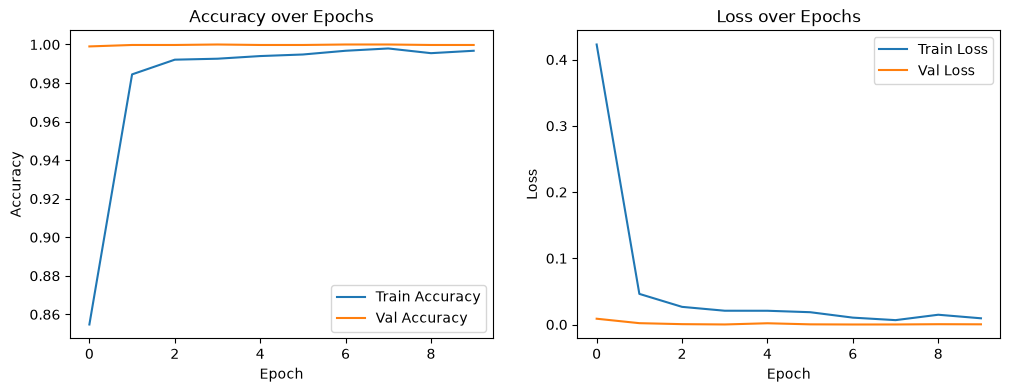

In [9]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show() 

In [10]:
data = []
labels = []
subject_ids = []

for subject in subjects:
    subject_path = os.path.join(dataset_path, subject)
    for gesture in gesture_classes:
        gesture_path = os.path.join(subject_path, gesture)
        for img_name in os.listdir(gesture_path):
            img_path = os.path.join(gesture_path, img_name)
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            img = cv2.resize(img, (img_size, img_size))
            data.append(img)
            labels.append(gesture)
            subject_ids.append(subject)

data = np.array(data)
labels = np.array(labels)
subject_ids = np.array(subject_ids)

data = data / 255.0
data = data.reshape(-1, img_size, img_size, 1)

print("Data shape:", data.shape)
print("Unique subjects:", np.unique(subject_ids))

Data shape: (20000, 64, 64, 1)
Unique subjects: ['00' '01' '02' '03' '04' '05' '06' '07' '08' '09']


In [11]:
train_subjects = ['00', '01', '02', '03', '04', '05', '06', '07']
test_subjects = ['08', '09']

train_mask = np.isin(subject_ids, train_subjects)
test_mask = np.isin(subject_ids, test_subjects)

X_train = data[train_mask]
X_test = data[test_mask]

y_train_labels = labels[train_mask]
y_test_labels = labels[test_mask]

print("Training samples:", X_train.shape)
print("Testing samples:", X_test.shape) 

Training samples: (16000, 64, 64, 1)
Testing samples: (4000, 64, 64, 1)


In [12]:
le = LabelEncoder()
le.fit(labels) 

y_train = to_categorical(le.transform(y_train_labels))
y_test = to_categorical(le.transform(y_test_labels))

print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)
print("Classes:", le.classes_) 

y_train shape: (16000, 10)
y_test shape: (4000, 10)
Classes: ['01_palm' '02_l' '03_fist' '04_fist_moved' '05_thumb' '06_index' '07_ok'
 '08_palm_moved' '09_c' '10_down']


In [13]:
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(img_size, img_size, 1)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test, y_test)
) 

C:\Users\AANYA SHARMA\Desktop\PRODIGY_ML_04\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 37s 70ms/step - accuracy: 0.8659 - loss: 0.3958 - val_accuracy: 0.7738 - val_loss: 1.3284
Epoch 2/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 35s 70ms/step - accuracy: 0.9858 - loss: 0.0429 - val_accuracy: 0.7703 - val_loss: 2.1804
Epoch 3/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 35s 70ms/step - accuracy: 0.9918 - loss: 0.0264 - val_accuracy: 0.7460 - val_loss: 2.3004
Epoch 4/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 35s 69ms/step - accuracy: 0.9928 - loss: 0.0227 - val_accuracy: 0.7665 - val_loss: 1.5712
Epoch 5/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 35s 70ms/step - accuracy: 0.9934 - loss: 0.0235 - val_accuracy: 0.8002 - val_loss: 1.7266
Epoch 6/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 36s 71ms/step - accuracy: 0.9953 - loss: 0.0158 - val_accuracy: 0.8090 - val_loss: 1.6338
Epoch 7/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 35s 71ms/step - accuracy: 0.9968 - loss: 0.0088 - val_accuracy: 0.8220 - val_loss: 1.9546
Epoch 8/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 35s 71ms/step - accuracy: 0.9949 - loss: 0.0127 - 

In [14]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1
)

datagen.fit(X_train) 

In [15]:
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(img_size, img_size, 1)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    datagen.flow(X_train, y_train, batch_size=32),
    epochs=15,
    validation_data=(X_test, y_test)
) 

Epoch 1/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 39s 73ms/step - accuracy: 0.7677 - loss: 0.6675 - val_accuracy: 0.8048 - val_loss: 0.5530
Epoch 2/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 36s 71ms/step - accuracy: 0.9611 - loss: 0.1192 - val_accuracy: 0.8673 - val_loss: 0.4343
Epoch 3/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 36s 72ms/step - accuracy: 0.9800 - loss: 0.0654 - val_accuracy: 0.8867 - val_loss: 0.2981
Epoch 4/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 36s 72ms/step - accuracy: 0.9848 - loss: 0.0525 - val_accuracy: 0.8840 - val_loss: 0.3464
Epoch 5/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 37s 73ms/step - accuracy: 0.9884 - loss: 0.0370 - val_accuracy: 0.9010 - val_loss: 0.4066
Epoch 6/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 37s 74ms/step - accuracy: 0.9904 - loss: 0.0288 - val_accuracy: 0.9345 - val_loss: 0.2708
Epoch 7/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 36s 72ms/step - accuracy: 0.9918 - loss: 0.0296 - val_accuracy: 0.9240 - val_loss: 0.2391
Epoch 8/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 36s 72ms/step - accuracy: 0.9933 - loss: 0.0221 - 

125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step
               precision    recall  f1-score   support

      01_palm       0.93      0.87      0.90       400
         02_l       0.96      0.90      0.93       400
      03_fist       0.78      0.87      0.82       400
04_fist_moved       0.85      0.76      0.80       400
     05_thumb       0.98      1.00      0.99       400
     06_index       0.94      0.96      0.95       400
        07_ok       1.00      1.00      1.00       400
08_palm_moved       0.93      1.00      0.97       400
         09_c       0.99      1.00      0.99       400
      10_down       1.00      1.00      1.00       400

     accuracy                           0.94      4000
    macro avg       0.94      0.94      0.93      4000
 weighted avg       0.94      0.94      0.93      4000



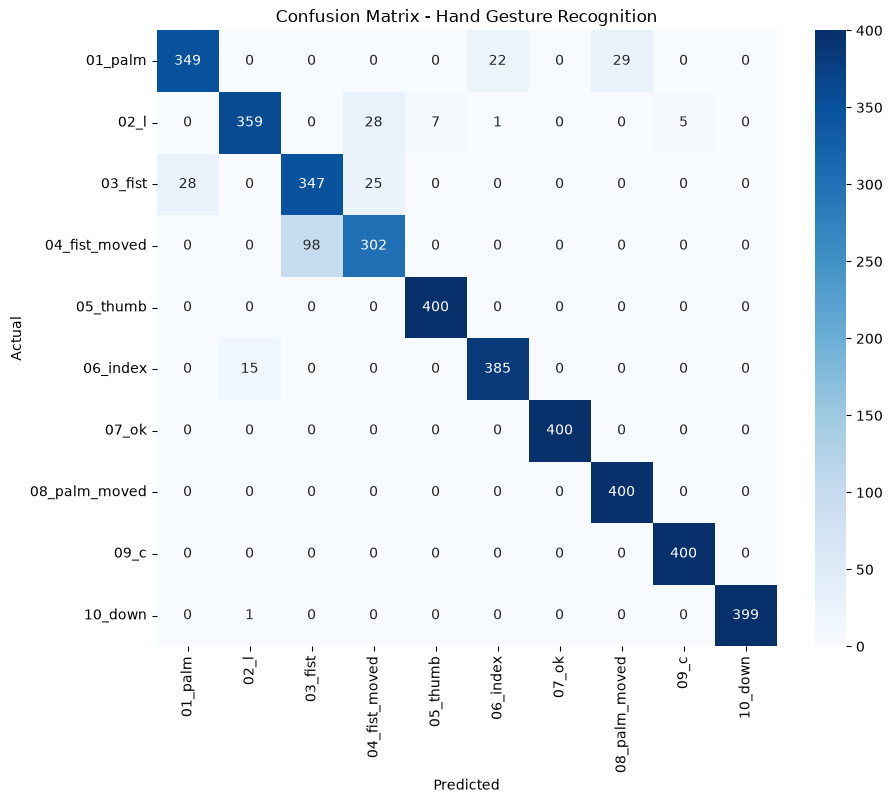

In [16]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Get predictions
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

# Classification report
print(classification_report(y_true, y_pred, target_names=le.classes_))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Hand Gesture Recognition')
plt.show() 

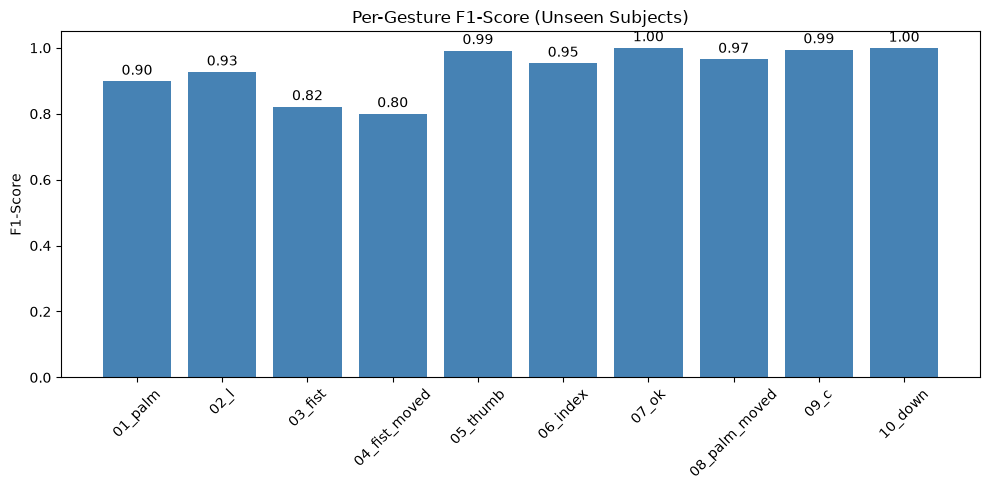

In [17]:
from sklearn.metrics import f1_score

f1_scores = f1_score(y_true, y_pred, average=None)

plt.figure(figsize=(10,5))
bars = plt.bar(le.classes_, f1_scores, color='steelblue')
plt.ylim(0, 1.05)
plt.ylabel('F1-Score')
plt.title('Per-Gesture F1-Score (Unseen Subjects)')
plt.xticks(rotation=45)

for bar, score in zip(bars, f1_scores):
    plt.text(bar.get_x() + bar.get_width()/2, score + 0.02, f'{score:.2f}', ha='center')

plt.tight_layout()
plt.show() 

In [18]:
model.save("gesture_recognition_model.h5")
print("Model saved successfully!") 

Model saved successfully!
